# Cell line layer sweep

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
sys.path.append('../../deconversation')
from pseudobulk import *
from preprocessing import *
from embeddings_1 import *
from deconvolution import *
from visualization import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [2]:
dataset_name = 'line'
reference_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/sub800_extracleanso_signature_matrix_symbol_id.csv'
bulk_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/GSE220605_DataMatrix_Mixture_CellLines_Bulk_RNA-seq_gene_ids.csv'
ground_truth_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/ground_truth.xlsx'

# Signature matrix
signature_df = pd.read_csv(reference_path, index_col=0)
signature_df = signature_df.T

# bulk data
bulk_df = pd.read_csv(bulk_path, index_col=0)
#bulk_df.index = gene_id_name_map(gene_list=bulk_df.index, mode='to_ensembl')
bulk_df = bulk_df.loc[bulk_df.index.dropna()]

# Ground truth
ground_truth = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/cell_lines_mixture_goundtruth.csv",
                       index_col=0)
ground_truth = ground_truth.replace('%', '', regex=True).astype(float).astype(int)
ground_truth = ground_truth/100

In [3]:
ground_truth.head()

,Jurkat,Thp1,BT474,MCF7,T47D,hMSC
Jurkat_1,1.0,0.0,0.0,0.0,0.0,0.0
Jurkat_2,1.0,0.0,0.0,0.0,0.0,0.0
Jurkat_3,1.0,0.0,0.0,0.0,0.0,0.0
Thp1_1,0.0,1.0,0.0,0.0,0.0,0.0
Thp1_2,0.0,1.0,0.0,0.0,0.0,0.0


In [5]:
def harmonize_columns(df):
    df = df.copy()
    return df

In [6]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/gf_layer_sweep/layer_sweep_metrics_zeroshot_cellline.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11.22it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.


/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:547: FutureWarning: Serie


Creating dataset.
Loading Geneformer model...


...

Loading Geneformer model...
Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Condition number: 23.42.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.1001.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9879.
Most similar pair: MCF7 vs T47D.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.02 seconds.
Running solver: simplex
Finished in 0.01 seconds.
Running solver: ridge_simplex
Finished in 0.01 seconds.
Running solver: dwls_simplex
Finished in 0.04 seconds.
Running solver: ridge
Finished in 0.03 seconds.
Running solver: elasticnet
Finished in 0.01 seconds.
Running solver: nusvr
Finished in 0.84 seconds.
Running solver: simplex_nnls
Finished in 0.01 seconds.
Running solver: gradient_descent


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.38 seconds.


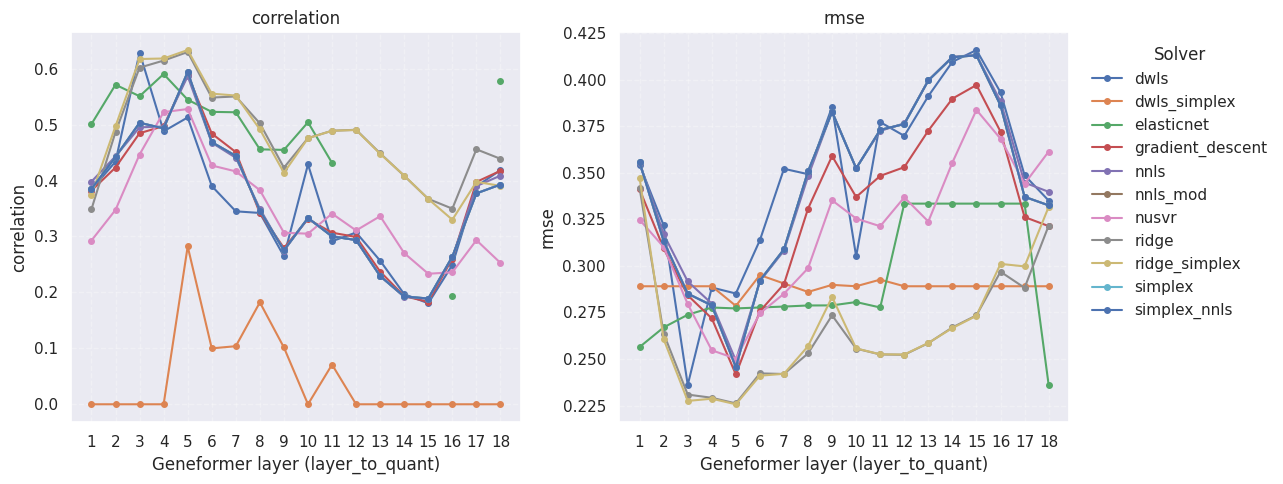

    layer            solver  correlation      rmse  meanCorrelation  meanRMSE
24      3              dwls     0.628889  0.236088         0.875561  0.208772
49      5      dwls_simplex     0.282220  0.278546         0.289847  0.277109
40      4        elasticnet     0.590483  0.277679         0.660366  0.276987
54      5  gradient_descent     0.589266  0.241718         0.812772  0.220322
44      5              nnls     0.586652  0.249188         0.841820  0.222614
45      5          nnls_mod     0.594270  0.245606         0.843796  0.220638
52      5             nusvr     0.527887  0.250175         0.812617  0.236856
50      5             ridge     0.629844  0.226160         0.724155  0.218291
48      5     ridge_simplex     0.633381  0.225694         0.732347  0.218101
47      5           simplex     0.594271  0.245606         0.843795  0.220637
53      5      simplex_nnls     0.594270  0.245606         0.843794  0.220637


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/gf_layer_sweep/layer_sweep_zeroshot_cellline.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])

### Fine-tuned 

In [9]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/',
        model_path='/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/geneformer/complete/finetuned/260204_geneformer_cellClassifier_cell_annot_subset/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/',
        model_path='/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/geneformer/complete/finetuned/260204_geneformer_cellClassifier_cell_annot_subset/ksplit1',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/gf_layer_sweep/layer_sweep_metrics_finetuned_cellline.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11.53it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


Some weights of BertForMaskedLM were not initialized from the model checkpoint at /gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/geneformer/complete/finetuned/260204_geneformer_cellClassifier_cell_annot_subset/ksplit1/ and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading Geneformer model...


...

Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Condition number: 4.92.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.3925.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.8134.
Most similar pair: BT474 vs MCF7.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.02 seconds.
Running solver: simplex
Finished in 0.03 seconds.
Running solver: ridge_simplex
Finished in 0.03 seconds.
Running solver: dwls_simplex
Finished in 0.06 seconds.
Running solver: ridge
Finished in 0.02 seconds.
Running solver: elasticnet
Finished in 0.01 seconds.
Running solver: nusvr
Finished in 0.98 seconds.
Running solver: simplex_nnls
Finished in 0.02 seconds.
Running solver: gradient_descent


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.37 seconds.


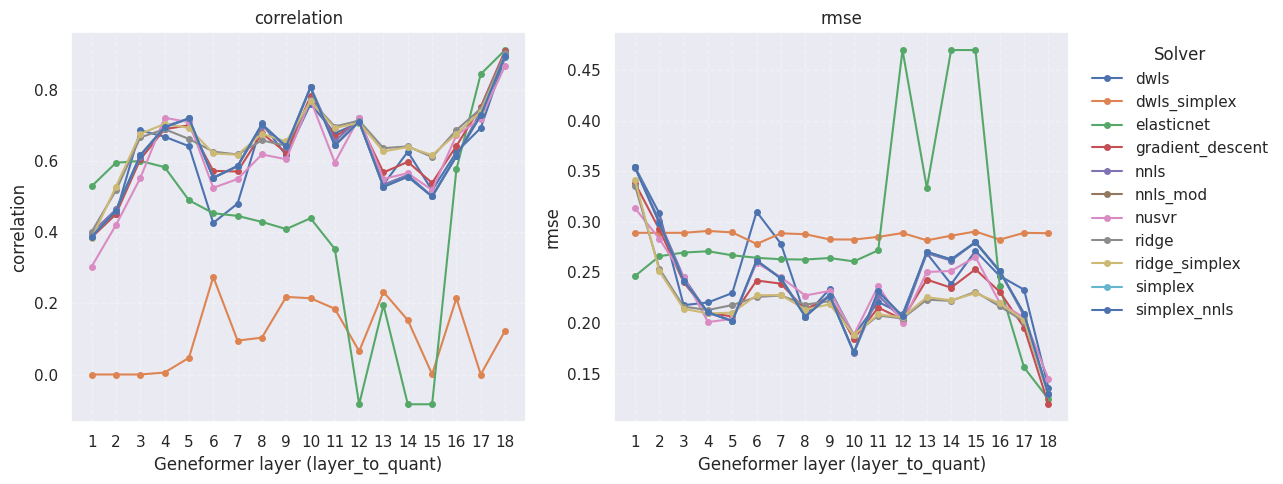

     layer            solver  correlation      rmse  meanCorrelation  meanRMSE
189     18              dwls     0.891913  0.136135         0.951510  0.116195
60       6      dwls_simplex     0.274560  0.278090         0.241211  0.277481
194     18        elasticnet     0.912139  0.124870         0.951298  0.106536
197     18  gradient_descent     0.910437  0.119664         0.954183  0.106213
187     18              nnls     0.904461  0.129695         0.954734  0.109306
188     18          nnls_mod     0.895567  0.129525         0.957718  0.111780
195     18             nusvr     0.868080  0.144697         0.952859  0.128250
193     18             ridge     0.904444  0.129499         0.954453  0.109417
191     18     ridge_simplex     0.895414  0.129496         0.957659  0.111939
190     18           simplex     0.895565  0.129525         0.957719  0.111782
196     18      simplex_nnls     0.895565  0.129525         0.957719  0.111782


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/gf_layer_sweep/layer_sweep_finetuned_cellline.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])